## Part 1: Setup and Imports

First, let's import all necessary libraries and set up our training device.

In [21]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
import pathlib

#add model folder to path
sys.path.insert(0, str(pathlib.Path().resolve().parent.parent.parent))

# Import training functions from gan_training module
from models.gan_training import train_gan, visualize_losses, analyze_convergence
from models.basic_gan import create_generator, create_discriminator

# Set random seed for reproducibility
torch.manual_seed(42)

# Determine device
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f" Setup complete. Using device: {device}")


 Setup complete. Using device: cpu


In [19]:
# Visualization helpers 
def plot_training_losses(d_losses, g_losses):
    """Plot discriminator and generator losses during training."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot D loss
    axes[0].plot(d_losses, linewidth=2, color="navy", label="D Loss")
    axes[0].axhline(y=0.5, color="red", linestyle="--", alpha=0.5, label="Ideal (0.5)")
    axes[0].axhline(
        y=np.log(2), color="gray", linestyle=":", alpha=0.5, label="Random (log2)"
    )
    axes[0].set_xlabel("Batch", fontsize=11)
    axes[0].set_ylabel("Loss", fontsize=11)
    axes[0].set_title("Discriminator Loss", fontsize=12, fontweight="bold")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Plot G loss
    axes[1].plot(g_losses, linewidth=2, color="darkgreen", label="G Loss")
    axes[1].set_xlabel("Batch", fontsize=11)
    axes[1].set_ylabel("Loss", fontsize=11)
    axes[1].set_title("Generator Loss", fontsize=12, fontweight="bold")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_sample_progression(generated_samples, checkpoint_intervals=5):
    """Display generated samples progression over training epochs."""
    num_checkpoints = len(generated_samples)
    cols = min(6, num_checkpoints)
    rows = (num_checkpoints + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(20, 3.5 * rows))
    axes = axes.flatten() if num_checkpoints > 1 else [axes]

    for checkpoint_idx, samples in enumerate(generated_samples):
        epoch_num = (checkpoint_idx + 1) * checkpoint_intervals
        ax = axes[checkpoint_idx]

        # Handle both grid tensors and batch tensors
        if len(samples.shape) == 4:
            # Batch of samples - make a grid
            grid_img = utils.make_grid(samples, nrow=4, normalize=True)
            grid_np = grid_img.squeeze().cpu().detach().numpy()
        else:
            # Already a grid
            grid_np = samples.squeeze().cpu().detach().numpy()

        if grid_np.ndim == 3 and grid_np.shape[0] == 3:
            grid_np = np.transpose(grid_np, (1, 2, 0))
            ax.imshow(grid_np)
        else:
            ax.imshow(grid_np, cmap="gray")

        ax.set_title(f"Epoch {epoch_num}", fontsize=10, fontweight="bold")
        ax.axis("off")

    # Hide unused subplots
    for idx in range(checkpoint_idx + 1, len(axes)):
        axes[idx].axis("off")

    plt.suptitle("Generated Samples Over Training", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()


print(" Visualization helpers loaded")


 Visualization helpers loaded


## Part 2: Load Fashion MNIST Dataset

### Task
TODO: Create data transforms and DataLoader for Fashion MNIST.

**Requirements:**
- Normalize images to [-1, 1] range (important for GAN training!)
- Batch size = 64
- Shuffle = True

**Hint:** Use `transforms.Compose()` to chain ToTensor and Normalize.

In [10]:
# TODO: Create transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# TODO: Load Fashion MNIST training dataset
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)

# TODO: Create DataLoader
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

print(f"Total images: {len(train_dataset)}")
print(f"Batch size: {batch_size}")
print(f"Batches per epoch: {len(train_loader)}")


100%|██████████| 26.4M/26.4M [00:04<00:00, 5.61MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 131MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.82MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 16.1MB/s]

Total images: 60000
Batch size: 64
Batches per epoch: 938


### Verification: Check Data Shape

Run this cell to verify your data loading is correct.

In [11]:
# Verification: Get a sample batch
sample_batch, sample_labels = next(iter(train_loader))
print(f"Sample batch shape: {sample_batch.shape}")
print(f"  Expected: torch.Size([64, 1, 28, 28])")
print(f"Sample labels shape: {sample_labels.shape}")
print(f"  Expected: torch.Size([64])")

# Check value range
print(f"\nImage values in range: [{sample_batch.min():.2f}, {sample_batch.max():.2f}]")
print(f"  Expected: [-1.0, 1.0]")

if (
    sample_batch.shape == torch.Size([64, 1, 28, 28])
    and -1.1 < sample_batch.min() < -0.9
    and 0.9 < sample_batch.max() < 1.1
):
    print("\n Data loading correct!")
else:
    print("\n Data loading has issues. Check the TODO section above.")


Sample batch shape: torch.Size([64, 1, 28, 28])
  Expected: torch.Size([64, 1, 28, 28])
Sample labels shape: torch.Size([64])
  Expected: torch.Size([64])

Image values in range: [-1.00, 1.00]
  Expected: [-1.0, 1.0]

 Data loading correct!


## Part 3: Visualize Sample Images

Let's look at some real Fashion MNIST images to understand what we're generating.

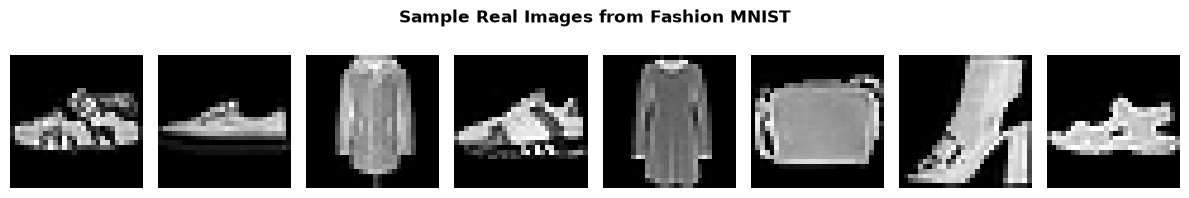

These are the types of images the GAN needs to learn to generate!


In [12]:
# Display 8 random samples from Fashion MNIST
fig, axes = plt.subplots(1, 8, figsize=(12, 2))

for i in range(8):
    ax = axes[i]
    img = sample_batch[i].squeeze().numpy()
    ax.imshow(img, cmap="gray")
    ax.axis("off")

plt.suptitle("Sample Real Images from Fashion MNIST", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

print("These are the types of images the GAN needs to learn to generate!")


## Part 4: Create Generator and Discriminator

### Task
TODO: Create the generator and discriminator models using functions from previous lessons.

**Requirements:**
- Use `create_generator()` with latent_dim=100
- Use `create_discriminator()`
- Move both to device

In [13]:
# TODO: Create generator
latent_dim = 100


# TODO: Create discriminator
generator = create_generator(latent_dim)
discriminator = create_discriminator()


# TODO: Move to device
generator = generator.to(device)
discriminator = discriminator.to(device)

print(f"Generator parameters: {sum(p.numel() for p in generator.parameters()):,}")
print(
    f"Discriminator parameters: {sum(p.numel() for p in discriminator.parameters()):,}"
)


Generator parameters: 293,136
Discriminator parameters: 533,505


## Part 5: Train the GAN

### Task
TODO: Call `train_gan()` to train both networks for 50 epochs.

**Requirements:**
- num_epochs = 50
- learning_rate = 0.0002
- beta1 = 0.5
- checkpoint_interval = 5
- verbose = True (to see progress)

**Note:** This will take 5-10 minutes depending on your device. 

**Expected Output:**
```
Epoch [1/50], Batch [N/M]
  D Loss: 0.6823 | G Loss: 0.8901 | Running D Avg: 0.6234
...
Training complete!
```

In [14]:
print("Starting GAN training...")
print("(This will take 5-10 minutes depending on your device)\n")

# TODO: Call train_gan() with appropriate parameters
d_losses, g_losses, generated_samples = train_gan(
    generator = generator,
    discriminator = discriminator,
    train_loader = train_loader,
    num_epochs = 50,
    device = device,
    lr = 0.0002,
    beta1 = 0.5,
    checkpoint_interval = 5,
    verbose = True
) 
print("\n Training complete!")


Starting GAN training...
(This will take 5-10 minutes depending on your device)

Starting GAN training for 50 epochs...
Device: cpu

Epoch 1/50 | D Loss: 0.2405 | G Loss: 2.9096
Epoch 2/50 | D Loss: 0.2837 | G Loss: 2.8454
Epoch 3/50 | D Loss: 0.3102 | G Loss: 2.5256
Epoch 4/50 | D Loss: 0.3267 | G Loss: 2.5343
Epoch 5/50 | D Loss: 0.3541 | G Loss: 2.2644
Epoch 6/50 | D Loss: 0.3759 | G Loss: 2.1419
Epoch 7/50 | D Loss: 0.3946 | G Loss: 2.0494
Epoch 8/50 | D Loss: 0.4054 | G Loss: 1.9410
Epoch 9/50 | D Loss: 0.4118 | G Loss: 1.8776
Epoch 10/50 | D Loss: 0.4269 | G Loss: 1.8103
Epoch 11/50 | D Loss: 0.4391 | G Loss: 1.7567
Epoch 12/50 | D Loss: 0.4396 | G Loss: 1.7204
Epoch 13/50 | D Loss: 0.4487 | G Loss: 1.6704
Epoch 14/50 | D Loss: 0.4536 | G Loss: 1.6525
Epoch 15/50 | D Loss: 0.4586 | G Loss: 1.6020
Epoch 16/50 | D Loss: 0.4564 | G Loss: 1.6100
Epoch 17/50 | D Loss: 0.4587 | G Loss: 1.5819
Epoch 18/50 | D Loss: 0.4592 | G Loss: 1.5723
Epoch 19/50 | D Loss: 0.4663 | G Loss: 1.5447
Ep

## Part 6: Analyze Loss Curves

### Task
TODO: Visualize discriminator and generator losses over time.

**What to Look For:**
- **D loss**: Should stabilize around 0.5-0.7 (balanced with G)
- **G loss**: Should decrease over time (learning to fool D)
- **Baseline**: Horizontal line at 0.693 (log(2), random guessing)

**Failure Modes:**
- ✗ D loss → 0: Generator collapsed (mode collapse)
- ✗ D loss → 1: Discriminator too good, G can't learn
- ✗ Wild oscillations: Unstable training
- ✓ Both curves smooth and stable: Training worked!

**Hint:** Use `visualize_losses()` function.

In [15]:
print("Visualizing loss curves...\n")

# TODO: Call visualize_losses() and display
# fig = visualize_losses(d_losses, g_losses)
# plt.show()

print("\nObservations from loss curves:")
print(f"  Discriminator - Initial: {d_losses[0]:.4f}, Final: {d_losses[-1]:.4f}")
print(f"  Generator - Initial: {g_losses[0]:.4f}, Final: {g_losses[-1]:.4f}")
print(f"  D Loss Range: [{min(d_losses):.4f}, {max(d_losses):.4f}]")
print(f"  G Loss Range: [{min(g_losses):.4f}, {max(g_losses):.4f}]")


Visualizing loss curves...


Observations from loss curves:
  Discriminator - Initial: 0.6886, Final: 0.4422
  Generator - Initial: 0.7022, Final: 2.0020
  D Loss Range: [0.0140, 1.5231]
  G Loss Range: [0.1075, 8.6888]


## Part 7: Detailed Loss Statistics

### Analysis
Print detailed statistics about the losses to understand training dynamics.

In [16]:
print("=" * 60)
print("LOSS STATISTICS")
print("=" * 60)

print("\nDiscriminator Loss:")
print(f"  Initial: {d_losses[0]:.4f}")
print(f"  Final: {d_losses[-1]:.4f}")
print(f"  Min: {min(d_losses):.4f}")
print(f"  Max: {max(d_losses):.4f}")
print(f"  Average: {np.mean(d_losses):.4f}")
print(f"  Std Dev: {np.std(d_losses):.4f}")

print("\nGenerator Loss:")
print(f"  Initial: {g_losses[0]:.4f}")
print(f"  Final: {g_losses[-1]:.4f}")
print(f"  Min: {min(g_losses):.4f}")
print(f"  Max: {max(g_losses):.4f}")
print(f"  Average: {np.mean(g_losses):.4f}")
print(f"  Std Dev: {np.std(g_losses):.4f}")

print("\n" + "=" * 60)


LOSS STATISTICS

Discriminator Loss:
  Initial: 0.6886
  Final: 0.4422
  Min: 0.0140
  Max: 1.5231
  Average: 0.4376
  Std Dev: 0.0780

Generator Loss:
  Initial: 0.7022
  Final: 2.0020
  Min: 0.1075
  Max: 8.6888
  Average: 1.6914
  Std Dev: 0.5642



## Part 8: Convergence Analysis

### Task
TODO: Use `analyze_convergence()` to detect failure modes and Nash Equilibrium.

**What It Checks:**
- Is D loss too low? (Mode collapse)
- Is D loss too high? (G can't learn)
- Are losses stable?
- Did both networks reach equilibrium?

**Expected Output:**
```
Recent 100 batches analysis:
  D Loss: avg=0.52, std=0.08 → STABLE
  G Loss: avg=0.89, std=0.12 → STABLE
  
Assessment:
  ✓ Discriminator performance: BALANCED
  ✓ Generator learning: IMPROVING
  ✓ Overall: LIKELY NASH EQUILIBRIUM
```

In [17]:
print("\n" + "=" * 60)
print("CONVERGENCE ANALYSIS")
print("=" * 60)

# TODO: Call analyze_convergence()
analyze_convergence(d_losses, g_losses)



CONVERGENCE ANALYSIS

CONVERGENCE ANALYSIS

Recent average losses (last 100 batches):
  Discriminator: 0.4514
  Generator: 1.6051

Loss stability (std dev):
  Discriminator: 0.0588
  Generator: 0.2749

Failure mode detection:
   BALANCED: D loss 0.4514
     Discriminator and Generator are in competition
   HIGH GENERATOR LOSS: 1.6051
     Generator struggles to fool discriminator

Nash Equilibrium characteristics:
  - D loss should stabilize around 0.5-0.7
  - G loss should decrease over time
  - Both losses should not oscillate wildly
  - Generated samples should improve with training


## Part 9: Visualize Generated Samples

### Task
TODO: Display generated samples from each checkpoint to see how quality improves over training.

**Expected Progression:**
- Epoch 5: Random noise-like patterns
- Epoch 10-15: Blurry shapes forming
- Epoch 20-30: Recognizable clothing items
- Epoch 40-50: Clear, detailed Fashion MNIST clothing

**Hint:** Loop through `generated_samples` list. Each item is a grid tensor from that epoch.

Visualizing generated samples over training...



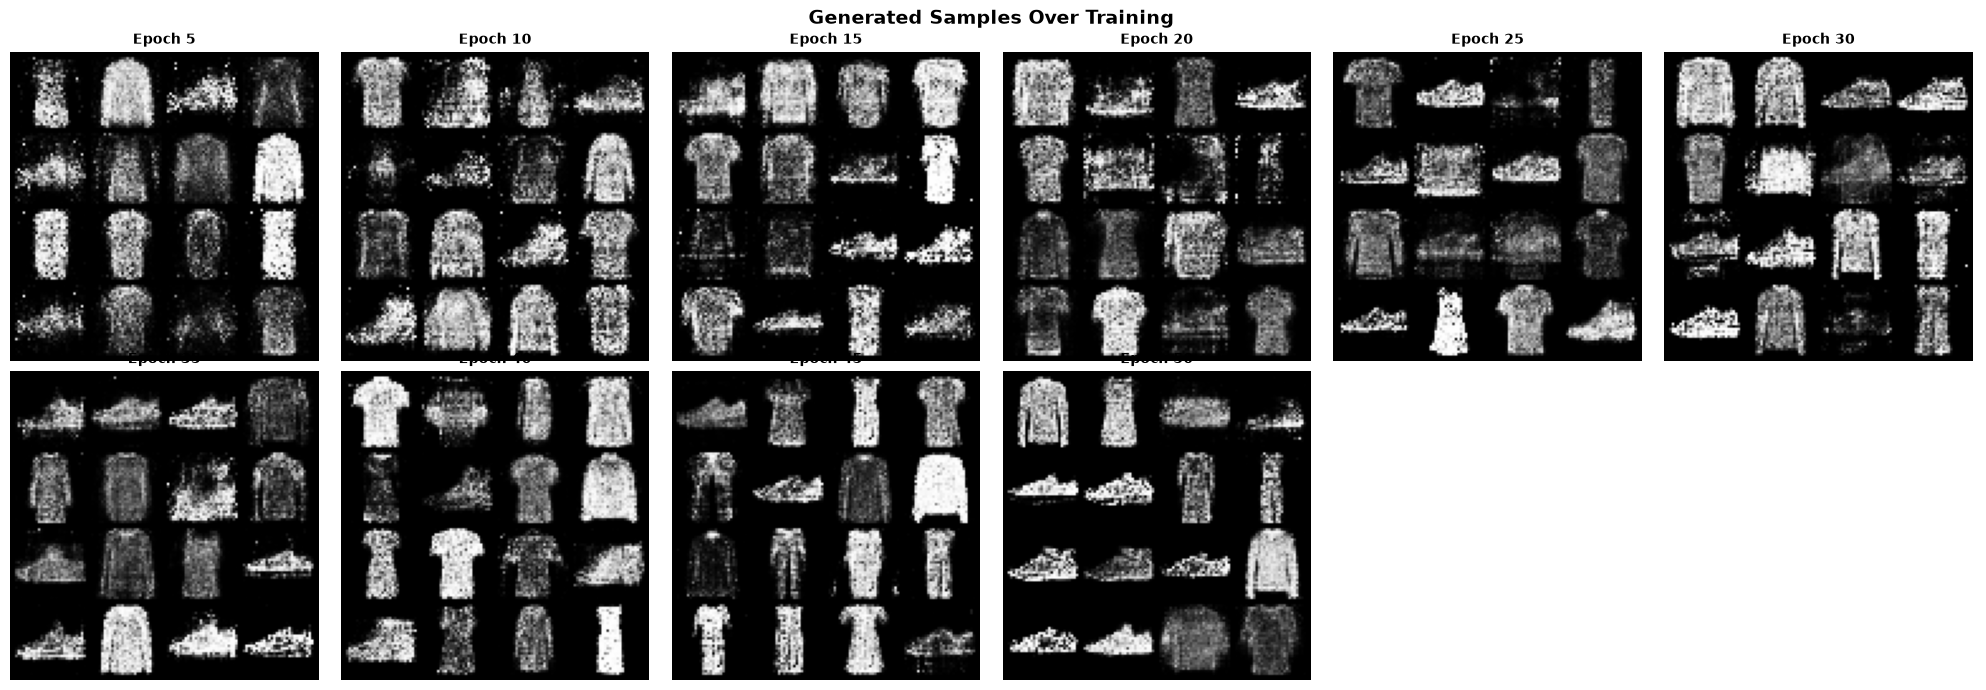

✓ Sample visualization complete


In [22]:
print("Visualizing generated samples over training...\n")


# Display sample progression using helper
plot_sample_progression(generated_samples, checkpoint_intervals=5)

print("✓ Sample visualization complete")


## Summary

**Key Takeaways:**

1. **GAN Training is an Adversarial Game**
   - D learns to classify real vs fake
   - G learns to fool D
   - Both compete for equilibrium

2. **Loss Curves Tell the Story**
   - Good: Both losses stabilize
   - Bad: D loss → 0 (mode collapse) or → 1 (D too strong)
   - Ideal: D loss around 0.5-0.7, G loss decreasing

3. **Nash Equilibrium in GANs**
   - Both networks reach stable performance point
   - Neither can improve further without making opponent worse
   - Indicates successful convergence

4. **Sample Quality Improves Over Time**
   - Early epochs: Random noise
   - Middle epochs: Emerging patterns
   - Late epochs: Clear, recognizable clothing

